# Telecom Customer Churn Analysis

## 04: Multivariate Analysis and Correlations

### Objective

This notebook extends the bivariate analysis by examining how multiple customer characteristics, service usage patterns, and billing factors interact with one another and relate to customer churn.

The analysis focuses on:

- Examining correlations among numerical customer, usage, and billing variables
- Investigating how multiple customer characteristics interact with churn
- Exploring whether churn patterns observed in the bivariate analysis remain consistent when additional variables are considered
- Examining interactions between tenure, contracts, offers, services, and billing characteristics
- Identifying overlapping relationships and potential confounding factors associated with customer churn

This builds on the bivariate analysis by moving beyond individual variable relationships and examining how combinations of factors may help explain customer behavior and churn patterns.

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [3]:
# Load cleaned dataset from first notebook
churn_df = pd.read_parquet('../data/processed/telecom_customer_churn_clean.parquet')

In [4]:
# Set visualization settings
sns.set_theme(style='white', 
              context='notebook', 
              palette='deep')

plt.rcParams['figure.figsize'] = (5, 3)
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.titlepad'] = 16
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['axes.labelpad'] = 6
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

### Correlation Analysis

##### Correlation Between Numerical Variables
- Investigate numerical customer, usage, and billing variables that could be strongly correlated.

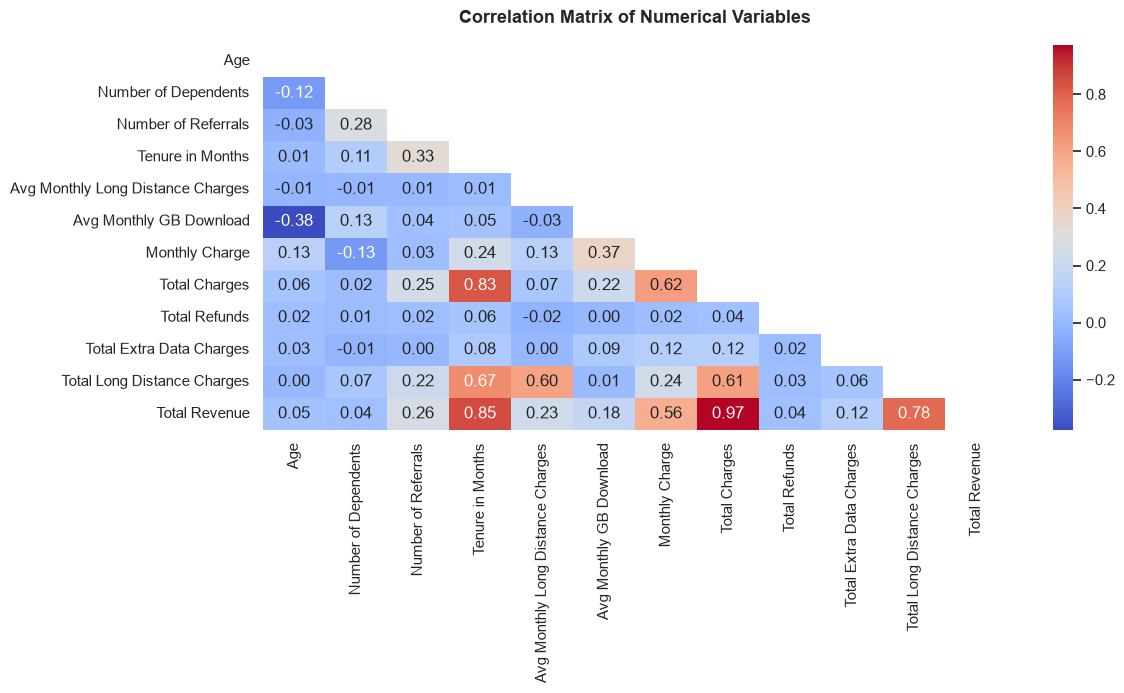

In [22]:
numerical_churn_df = (churn_df[['Age', 'Number of Dependents', 'Number of Referrals', 
                                'Tenure in Months', 'Avg Monthly Long Distance Charges', 
                                'Avg Monthly GB Download', 'Monthly Charge', 'Total Charges', 
                                'Total Refunds', 'Total Extra Data Charges', 'Total Long Distance Charges', 
                                'Total Revenue']])

plt.figure(figsize=(12, 5))
sns.heatmap(
    numerical_churn_df.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    mask=np.triu(np.ones_like(numerical_churn_df.corr()))
)

plt.xticks(rotation=90)
plt.title('Correlation Matrix of Numerical Variables');

The strongest correlations are primarily found among tenure and cumulative financial variables. Tenure is strongly positively correlated with Total Charges, Total Long Distance Charges, and Total Revenue, which is expected because these values accumulate throughout a customer's relationship with the company. Total Charges and Total Revenue show the strongest correlation (r = 0.97).

Outside of these cumulative relationships, correlations are generally weak to moderate. Notable relationships include Age and Avg Monthly GB Download (r = -0.38), Avg Monthly GB Download and Monthly Charge (r = 0.37), and Number of Referrals and Tenure (r = 0.33). Overall, most customer characteristics and monthly usage variables do not exhibit strong linear relationships with one another.

It is also important to note that the correlation matrix includes all customers. Some service-specific variables contain structural zero values for customers who do not subscribe to the corresponding service. Therefore, correlations involving variables such as Avg Monthly GB Download and Avg Monthly Long Distance Charges should be interpreted with caution.

<Axes: xlabel='Age', ylabel='Avg Monthly GB Download'>

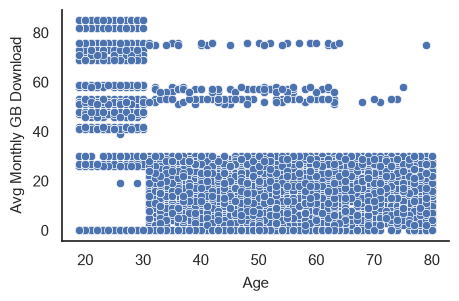

In [25]:
sns.scatterplot(
    churn_df,
    x='Age',
    y='Avg Monthly GB Download'
)

### Customer Profile, Tenure, and Churn

### Services, Billing, and Churn

### Contracts, Offers, and Churn

### Key Multivariate Churn Patterns